# Лабораторная работа  
## Тема: K ближайших соседей

### 1. Краткая информация о методе

Метод **K ближайших соседей** — это алгоритм классификации, который определяет класс нового объекта по классам его ближайших соседей в пространстве признаков.  
Смысл метода простой: если объект по своим признакам похож на объекты определённого класса, то модель относит его к этому классу.

В данной работе решается задача классификации качества вина.  
По физико-химическим признакам и типу вина модель определяет, относится ли вино к категории:
- **1 — хорошее качество**
- **0 — обычное или низкое качество**

Для лабораторной выбран понятный и достаточно большой датасет: объединённый набор красного и белого вина.  
Размер датасета — **6497 объектов**, что заметно лучше для учебной демонстрации, чем слишком маленькие наборы данных.


### 2. Используемые библиотеки

В работе используются:
- **pandas** — для работы с таблицами;
- **numpy** — для численных операций;
- **matplotlib** и **seaborn** — для построения графиков;
- **scikit-learn** — для подготовки данных, обучения модели и оценки качества.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

plt.style.use("dark_background")
pd.set_option("display.max_columns", None)


### 3. Описание датасета

Используется объединённый датасет **Wine Quality**.  
В него входят данные о красном и белом вине. Для каждого объекта известны физико-химические признаки:

- fixed acidity — фиксированная кислотность  
- volatile acidity — летучая кислотность  
- citric acid — лимонная кислота  
- residual sugar — остаточный сахар  
- chlorides — хлориды  
- free sulfur dioxide — свободный диоксид серы  
- total sulfur dioxide — общий диоксид серы  
- density — плотность  
- pH — кислотность среды  
- sulphates — сульфаты  
- alcohol — содержание алкоголя  
- wine_type — тип вина: red или white  

Исходная колонка `quality` содержит числовую оценку качества.  
Для задачи классификации создаётся новый целевой признак `quality_label`:

- **1**, если качество вина **6 и выше**
- **0**, если качество вина **меньше 6**

Такой вариант удобен для бинарной классификации.


In [2]:
from pathlib import Path

candidate_paths = [
    Path("wine_quality_combined.csv"),
    Path("/mnt/data/wine_quality_combined.csv")
]

for p in candidate_paths:
    if p.exists():
        df = pd.read_csv(p)
        break
else:
    raise FileNotFoundError("Файл wine_quality_combined.csv не найден рядом с ноутбуком.")

print("Размер датасета:", df.shape)
display(df.head())


Размер датасета: (6497, 14)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1


In [3]:
print("Типы данных:")
print(df.dtypes)
print()
print("Количество пропусков:")
print(df.isnull().sum())


Типы данных:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
wine_type                   str
quality_label             int64
dtype: object

Количество пропусков:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
quality_label           0
dtype: int64


In [4]:
print("Распределение целевой переменной:")
print(df["quality_label"].value_counts())


Распределение целевой переменной:
quality_label
1    4113
0    2384
Name: count, dtype: int64


### 4. Предобработка данных

Перед обучением модели выполняются следующие действия:

1. Отделяются признаки от целевой переменной.  
2. Числовые признаки заполняются медианой при наличии пропусков.  
3. Категориальный признак `wine_type` заполняется самым частым значением и переводится в числовой вид.  
4. Числовые признаки масштабируются, так как для метода K ближайших соседей расстояния между объектами очень важны.  
   Если признаки измеряются в разных единицах, более крупные по масштабу признаки начинают влиять слишком сильно.


In [6]:
X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)


Числовые признаки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Категориальные признаки: ['wine_type']


In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (5197, 12)
Размер тестовой выборки: (1300, 12)


### 5. Тепловая карта корреляций

Тепловая карта показывает, как числовые признаки связаны друг с другом и с целевой переменной `quality_label`.  
Значения ближе к **1** означают прямую связь, значения ближе к **-1** — обратную связь.

Для более понятной визуализации используется карта по всем числовым признакам и целевому признаку.


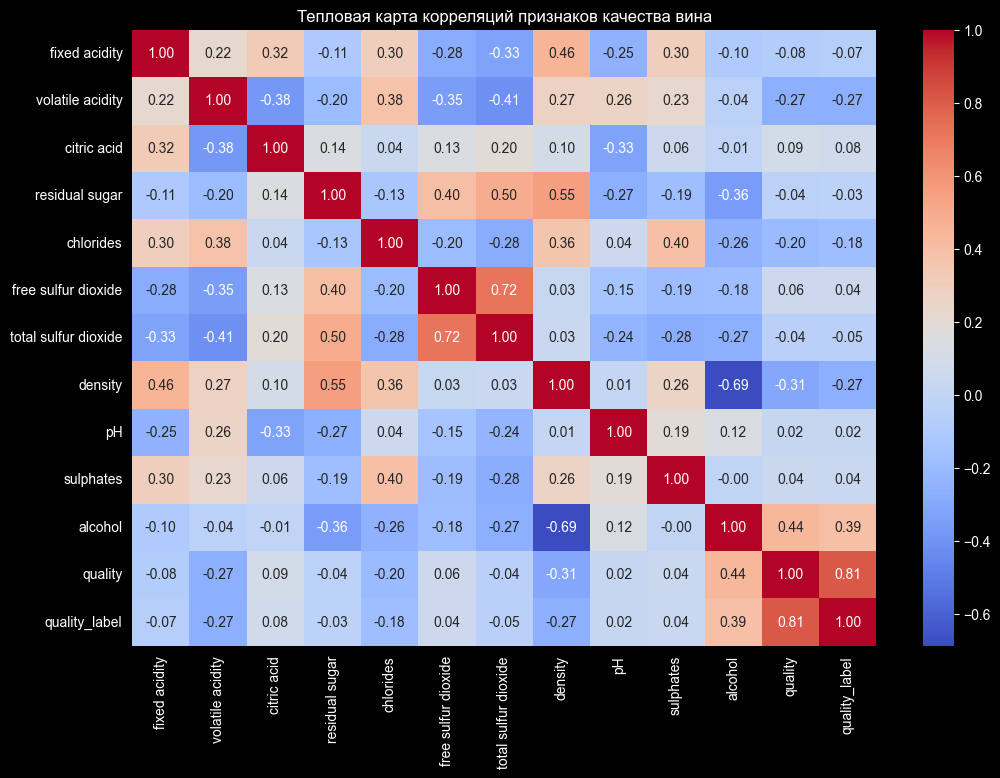

Признаки с наиболее заметной связью с quality_label:
alcohol                 0.394676
density                -0.268876
volatile acidity       -0.267046
chlorides              -0.181908
citric acid             0.075739
fixed acidity          -0.067354
total sulfur dioxide   -0.047585
free sulfur dioxide     0.044819
Name: quality_label, dtype: float64


In [8]:
corr_df = df.drop(columns=["wine_type"]).copy()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Тепловая карта корреляций признаков качества вина")
plt.show()

target_corr = corr_df.corr()["quality_label"].drop(["quality", "quality_label"]).sort_values(key=lambda x: x.abs(), ascending=False)
print("Признаки с наиболее заметной связью с quality_label:")
print(target_corr.head(8))


### 6. Обучение модели

Для обучения используется классификатор **KNeighborsClassifier**.  
Параметр `n_neighbors=7` означает, что при определении класса нового объекта учитываются 7 ближайших соседей.


In [9]:
knn_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)


### 7. Оценка качества модели

Для оценки качества используются метрики:
- **Accuracy** — общая доля правильных ответов;
- **Precision** — точность положительных предсказаний;
- **Recall** — полнота;
- **F1-score** — сбалансированная метрика между precision и recall.


In [10]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.7631
Precision: 0.7970
Recall: 0.8396
F1-score: 0.8178


In [11]:
print("Подробный отчёт классификации:")
print(classification_report(y_test, y_pred, target_names=["low_or_normal", "good"]))


Подробный отчёт классификации:
               precision    recall  f1-score   support

low_or_normal       0.70      0.63      0.66       477
         good       0.80      0.84      0.82       823

     accuracy                           0.76      1300
    macro avg       0.75      0.74      0.74      1300
 weighted avg       0.76      0.76      0.76      1300



### 8. Матрица ошибок

Матрица ошибок показывает, сколько объектов модель определила правильно и где допустила ошибки.
- диагональные элементы — правильные ответы;
- вне диагонали — ошибки классификации.


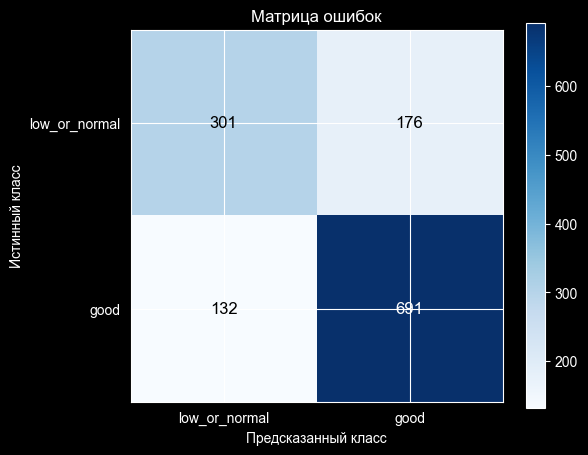

Матрица ошибок:
[[301 176]
 [132 691]]


In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks([0, 1], ["low_or_normal", "good"])
plt.yticks([0, 1], ["low_or_normal", "good"])

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=12)

plt.colorbar()
plt.show()
print("Матрица ошибок:")
print(cm)


### 9. Графики результатов

Ниже показаны:
1. сравнение основных метрик модели;
2. валидационная кривая по параметру `n_neighbors`.

Валидационная кривая помогает понять, при каком количестве соседей модель работает лучше.


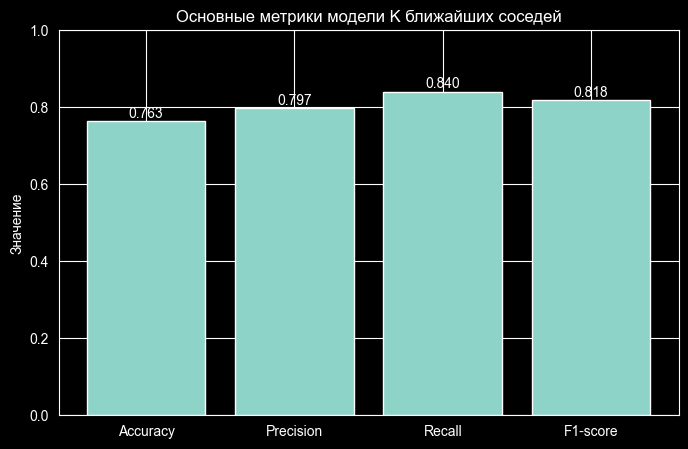

In [13]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_values = [acc, prec, rec, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values)
plt.ylim(0, 1)
plt.title("Основные метрики модели K ближайших соседей")
plt.ylabel("Значение")

for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center")

plt.show()


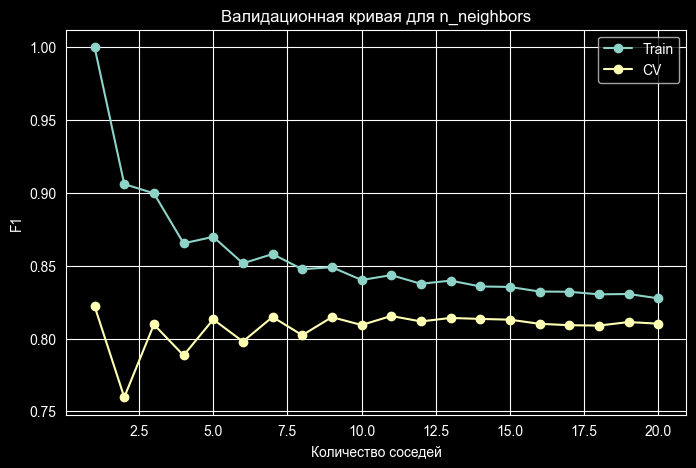

In [14]:
param_range = np.arange(1, 21)

train_scores, test_scores = validation_curve(
    knn_clf,
    X_train,
    y_train,
    param_name="model__n_neighbors",
    param_range=param_range,
    cv=5,
    scoring="f1"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, marker="o", label="Train")
plt.plot(param_range, test_mean, marker="o", label="CV")
plt.title("Валидационная кривая для n_neighbors")
plt.xlabel("Количество соседей")
plt.ylabel("F1")
plt.legend()
plt.show()


### 10. Вывод

В работе был рассмотрен метод **K ближайших соседей** для задачи классификации качества вина.  
В качестве датасета использован объединённый набор красного и белого вина, содержащий **6497 объектов**.

По результатам эксперимента можно сделать вывод, что метод K ближайших соседей способен достаточно хорошо решать задачу бинарной классификации при корректной предобработке данных и масштабировании признаков.  
Особенно важно, что перед обучением числовые признаки были приведены к сопоставимому масштабу, так как метод основан на расстояниях между объектами.

Также было показано, как с помощью тепловой карты и валидационной кривой можно анализировать данные и подбирать параметры модели.
